# PNCBF + Robust CBF Filters: Double Integrator

Loads a pre-trained PNCBF checkpoint and uses `alg.get_Vh(x)` as the CBF
in place of the hand-crafted HOCBF.  The Lie derivatives
`Lf_V = J_V(x)·f(x)` and `LG_V = J_V(x)·G(x)` are computed by differentiating
through the neural network, so `proj_grad_max_box` works unchanged —
it just propagates gradients through the Hessian of V.

Compares four policies: CBF · R-CBF-QP · G-CBF (NNV) · Duality CBF


In [101]:
import functools as ft
import pathlib
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from typing import NamedTuple
import time

import jax_verify
from jax_verify.src import bound_propagation

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp, rcbf_qp_linear, compute_rcbf_gammas
from mrncbf.dyn.doubleint_wall import DoubleIntWall
from mrncbf.pncbf.pncbf import PNCBF
from mrncbf.utils.ckpt_utils import load_ckpt
import run_config.int_avoid.doubleintwall_cfg

jax_default_x32()

# ── Checkpoint path — set this to your trained run ───────────────────────────
CKPT_PATH = pathlib.Path(
    "../../runs/pncbf_dbint/2026-04-15_16-55_MXOC_acl-lambda-01_dbint/ckpts/5000"
)

# ── QP / filter parameters ───────────────────────────────────────────────────
ALPHA_QP  = 0.01    # CBF-QP alpha (small: neural V is not Lipschitz-normalised)
V_SHIFT   = 1e-2    # widen the safe set slightly (avoids chattering at V=0)
PWALL     = 1.0
u_lb      = jnp.array([-1.0])
u_ub      = jnp.array([ 1.0])

# ── Observation / estimator parameters ──────────────────────────────────────
OBS_A    = 4.0
OBS_B    = 4.0
OBS_BETA = 0.5
OBS_EPS  = jnp.array([0.1, 0.1])


2026-04-19 13:51:47.672 | INFO     | mrncbf.pncbf.pncbf:create:175 - Discount lam: Constant(value=0.4)
/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/orbax/checkpoint/type_handlers.py:1401: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Loaded checkpoint from ../../runs/pncbf_dbint/2026-04-15_16-55_MXOC_acl-lambda-01_dbint/ckpts/5000
Task: nh=2  nx=2  nu=1  dt=0.1


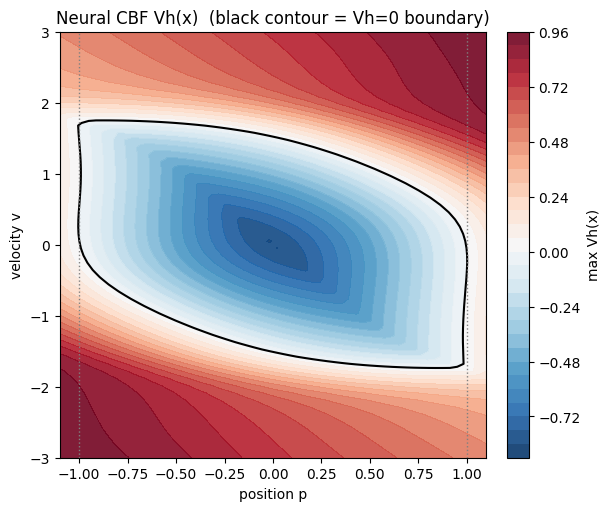

In [102]:
seed = 0
task = DoubleIntWall()
CFG  = run_config.int_avoid.doubleintwall_cfg.get(seed)
alg  = PNCBF.create(seed, task, CFG.alg_cfg, task.nom_pol_rng3)
# Restore to whichever device JAX has initialised — handles cuda:0/cuda:1 mismatch
with jax.default_device(jax.devices()[0]):
    alg = load_ckpt(alg, CKPT_PATH.absolute())
print(f"Loaded checkpoint from {CKPT_PATH}")
print(f"Task: nh={task.nh}  nx={task.nx}  nu={task.nu}  dt={task.dt}")

DT = task.dt
DT = 0.1
T  = 60

# ── dynamics (same as task, but as plain JAX fns for convenience) ─────────────
def f(x): return task.f(x)
def G(x): return task.G(x)

_NH = task.nh   # = 2

# ── Neural CBF: V_h(x) + V_SHIFT so that V<0 is the padded safe set ──────────
def B_nn(x):
    return alg.get_Vh(x) + V_SHIFT

def _gcbf_ingredients(x):
    h_V   = B_nn(x)
    hx_Vx = jax.jacobian(B_nn)(x)    # (nh, nx) — Hessian goes through neural net
    return h_V, hx_Vx @ f(x), hx_Vx @ G(x)

# ── Visualise Vh on the phase plane ──────────────────────────────────────────
n_pts = 60
ps = np.linspace(-1.1, 1.1, n_pts)
vs = np.linspace(-3.0, 3.0, n_pts)
PP, VV = np.meshgrid(ps, vs)
grid_x  = jnp.array(np.stack([PP.ravel(), VV.ravel()], axis=1))
Vh_grid = jax.vmap(alg.get_Vh)(grid_x).max(axis=-1)   # (n_pts^2,) max over constraints
Vh_grid = np.array(Vh_grid).reshape(n_pts, n_pts)

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
cs = ax.contourf(PP, VV, Vh_grid, levels=31, cmap='RdBu_r', alpha=0.9)
ax.contour(PP, VV, Vh_grid, levels=[0.0], colors=['k'], linewidths=1.5)
fig.colorbar(cs, ax=ax, label='max Vh(x)')
for xw in [-PWALL, PWALL]: ax.axvline(xw, color='gray', lw=1.0, ls=':')
ax.set_xlabel('position p'); ax.set_ylabel('velocity v')
ax.set_title('Neural CBF Vh(x)  (black contour = Vh=0 boundary)')
plt.show()


## Observation model and NNV state bounds

In [103]:
def obs_fn(x):
    p, v = x
    obs_p = -1.0 / OBS_B * jnp.log(OBS_A / (p + OBS_A - 1.0) - 1.0)
    obs_v = v / OBS_BETA
    return jnp.array([obs_p, obs_v])

def estimator_fn(obs):
    p_hat = OBS_A * jax.nn.sigmoid(OBS_B * obs[0]) - (OBS_A - 1.0)
    v_hat = OBS_BETA * obs[1]
    return jnp.array([p_hat, v_hat])

class StateBounds(NamedTuple):
    lo: jnp.ndarray
    hi: jnp.ndarray

@jax.jit
def nnv_state_bounds(obs, obs_eps):
    ib = jax_verify.IntervalBound(obs - obs_eps, obs + obs_eps)
    def propagate(inp_bound):
        (inp_bound,) = bound_propagation.unjit_inputs(inp_bound)
        bounds = jax_verify.backward_crown_bound_propagation(estimator_fn, inp_bound)
        return jnp.array(bounds.lower), jnp.array(bounds.upper)
    lo, hi = propagate(ib.to_jittable())
    return StateBounds(lo=lo.flatten(), hi=hi.flatten())

x_chk = jnp.array([0.5, -0.3])
err   = jnp.max(jnp.abs(estimator_fn(obs_fn(x_chk)) - x_chk))
print(f"Roundtrip error: {float(err):.2e}")
sb = nnv_state_bounds(obs_fn(x_chk), OBS_EPS)
print(f"NNV bounds: lo={np.array(sb.lo).round(4)}  hi={np.array(sb.hi).round(4)}")


Roundtrip error: 0.00e+00
NNV bounds: lo=[ 0.2973 -0.35  ]  hi=[ 0.675 -0.25 ]


## Rollout infrastructure

In [104]:
BASE_KEY = jax.random.PRNGKey(0)
OBS_PTB  = OBS_EPS * jnp.array([1.0, 0.0])

REF_INITIAL     = -0.95
REF_FINAL       =  0.95
REF_SWITCH_STEP = 50   # steps (50 * dt = 5 s)

refs = jnp.where(jnp.arange(T) >= REF_SWITCH_STEP,
                 jnp.full(T, REF_FINAL), jnp.full(T, REF_INITIAL))

ts      = np.arange(T + 1) * DT
ts_ctrl = np.arange(T) * DT

def _make_rollout_aux(step_fn):
    @jax.jit
    def rollout(x0):
        _, (xs, xhats, los, his) = jax.lax.scan(
            step_fn, x0, (jnp.arange(T), refs))
        return jnp.concatenate([x0[None], xs], axis=0), xhats, los, his
    return rollout

def _perturb_obs(x, key):
    obs = obs_fn(x) + jax.random.uniform(key, OBS_PTB.shape,
                                          minval=OBS_PTB - 1e-4, maxval=OBS_PTB)
    return obs, estimator_fn(obs)

def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def gcbf_pol_gradopt_box(xhat, lo, hi, rng_key, ref,
                          alpha_qp=ALPHA_QP, n_restarts=8, n_steps=40, lr=0.05):
    keys = jax.random.split(rng_key, 3 * _NH)
    def worst_h_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: B_nn(x)[i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[0][i]
    def worst_Lf_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: _gcbf_ingredients(x)[1][i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[1][i]
    def worst_LG_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: -jnp.linalg.norm(_gcbf_ingredients(x)[2][i]),
                                  lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[2][i]
    ci = jnp.arange(_NH)
    h_V_wc  = jax.vmap(worst_h_V_i )(ci, keys[      : _NH  ])
    h_Lf_wc = jax.vmap(worst_Lf_V_i)(ci, keys[  _NH : 2*_NH])
    h_LG_wc = jax.vmap(worst_LG_V_i)(ci, keys[2*_NH :      ])
    u_nom   = jnp.array([-2.0*(xhat[0] - ref) - 1.5*xhat[1]]).clip(-1, 1)
    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub, h_V_wc, h_Lf_wc, h_LG_wc, u_nom,
                           relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc

def nom_pol(x, ref):
    return jnp.array([-2.0*(x[0] - ref) - 1.5*x[1]]).clip(-1, 1)

# ── CBF step ──────────────────────────────────────────────────────────────────
def _cbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs, xhat = _perturb_obs(x, key)
    h_V   = B_nn(xhat)
    hx_Vx = jax.jacobian(B_nn)(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_V, hx_Vx,
                           f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, xhat, xhat)

rollout_cbf_aux = _make_rollout_aux(_cbf_step_aux)

# ── G-CBF step ────────────────────────────────────────────────────────────────
def _gcbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, qp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, sb.lo, sb.hi, qp_key, ref)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, sb.lo, sb.hi)

rollout_gcbf_aux = _make_rollout_aux(_gcbf_step_aux)

x_dummy = jnp.array([0.5, 0.5])
print("Compiling CBF and G-CBF rollouts...")
rollout_cbf_aux(x_dummy); rollout_gcbf_aux(x_dummy)
print("Done.")


Compiling CBF and G-CBF rollouts...
Done.


  CBF               violated: True
  G-CBF (NNV)       violated: True


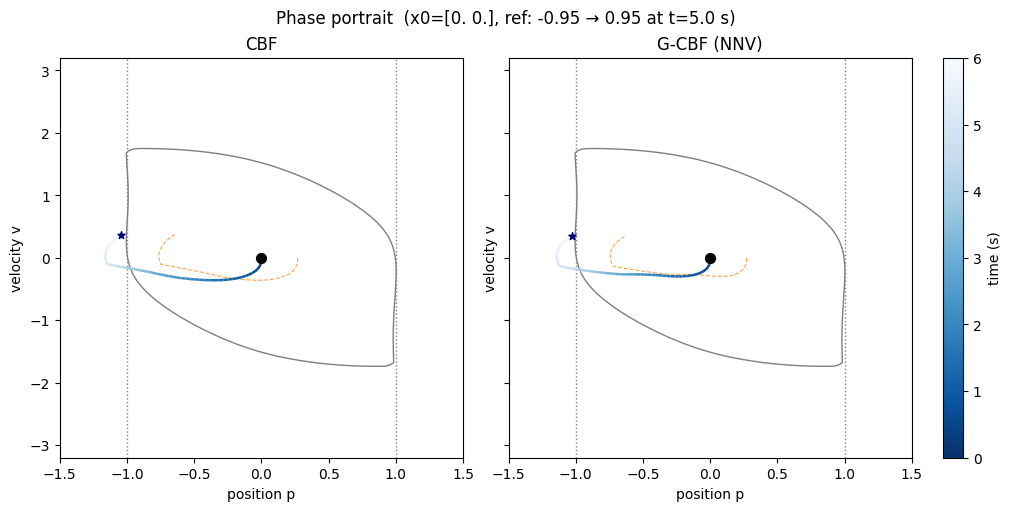

In [105]:
x0s = jnp.array([
    [ 0.0,  0.0],
    [ 0.8,  0.8],
    [-0.8, -0.8],
    [ 0.6, -0.6],
    [-0.6,  0.6],
])
X0_IDX  = 0
x0_demo = x0s[X0_IDX]

ref_sched = np.where(np.arange(T) >= REF_SWITCH_STEP, float(REF_FINAL), float(REF_INITIAL))

results_aux = {}
for name, fn in [("CBF", rollout_cbf_aux), ("G-CBF (NNV)", rollout_gcbf_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[name] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    print(f"  {name:<16}  violated: {viol}")

# ── Phase plots ───────────────────────────────────────────────────────────────
def plot_phase(ax):
    ax.contour(PP, VV, Vh_grid, levels=[0.0], colors=['k'], linewidths=1.0, alpha=0.5)
    for xw in [-PWALL, PWALL]: ax.axvline(xw, color='gray', lw=1.0, ls=':')
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel('position p'); ax.set_ylabel('velocity v')

fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained",
                          sharex=True, sharey=True)
for ax, (name, d) in zip(axes, results_aux.items()):
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color='C1', lw=0.8, ls='--', alpha=0.7, label='x̂')
    ax.scatter(*xs[0],  s=50, color='k',    zorder=7)
    ax.scatter(*xs[-1], s=30, color='navy', marker='*', zorder=7)
    plot_phase(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle(f'Phase portrait  (x0={np.array(x0_demo).round(2)}, '
             f'ref: {REF_INITIAL} → {REF_FINAL} at t={REF_SWITCH_STEP*DT:.1f} s)')
plt.show()


## All policies: R-CBF-QP and Duality CBF

For the neural CBF, `LG_V = J_V(x)·G(x)` varies with x (non-constant network Jacobian),
so the uncertainty image is a curved 1D manifold in 2D space rather than a line segment.
`N_PLANES_DUAL = 8` gives good coverage; reduce to 2 if performance is identical.


In [106]:
import itertools

# All 2^nx corners of the NNV bounding box — exact worst-case over the box vertices.
# Since nx=2, there are 4 corners: (±1, ±1) scaled by half-width.
_CORNER_SIGNS = jnp.array(list(itertools.product(*[[-1.0, 1.0]] * 2)))  # (4, 2)

def _gcbf_corners_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, _ = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    mid     = 0.5 * (hi + lo)
    half    = 0.5 * (hi - lo)
    corners = mid[None] + half[None] * _CORNER_SIGNS   # (4, nx)

    # Evaluate CBF ingredients at all corners
    h_V_c, Lf_c, LG_c = jax.vmap(_gcbf_ingredients)(corners)  # each (4, nh), (4, nh), (4, nh, nu)

    # Independent worst case per constraint:
    #   worst h_V: largest (most dangerous)
    #   worst Lf:  largest (hardens constraint)
    #   worst LG:  smallest norm (hardest to satisfy)
    ci      = jnp.arange(_NH)
    wc_h    = jnp.argmax(h_V_c,                              axis=0)   # (nh,)
    wc_Lf   = jnp.argmax(Lf_c,                               axis=0)   # (nh,)
    wc_LG   = jnp.argmin(jnp.linalg.norm(LG_c, axis=-1),    axis=0)   # (nh,)

    h_V_wc  = h_V_c[wc_h,  ci]          # (nh,)
    Lf_wc   = Lf_c [wc_Lf, ci]          # (nh,)
    LG_wc   = LG_c [wc_LG, ci, :]       # (nh, nu)

    u_nom_val = nom_pol(xhat, ref)
    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub, h_V_wc, Lf_wc, LG_wc,
                       u_nom_val, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_gcbf_corners_aux = _make_rollout_aux(_gcbf_corners_step_aux)

print("Compiling G-CBF (corners)...")
rollout_gcbf_corners_aux(x_dummy)
print("Done.")


Compiling G-CBF (corners)...
Done.


In [107]:
# G-CBF with random sampling over the NNV bounding box.
# Samples N random states from the box, evaluates CBF ingredients at each,
# then takes independent worst case per constraint — more coverage than corners.

N_GCBF_SAMPLES = 64

def _gcbf_sampling_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, samp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi

    # Sample N_GCBF_SAMPLES points uniformly in [lo, hi]
    samples = lo[None] + jax.random.uniform(
        samp_key, shape=(N_GCBF_SAMPLES, lo.shape[0])
    ) * (hi - lo)                                      # (N, nx)

    # Evaluate ingredients at all samples
    h_V_s, Lf_s, LG_s = jax.vmap(_gcbf_ingredients)(samples)  # (N,nh), (N,nh), (N,nh,nu)

    ci      = jnp.arange(_NH)
    wc_h    = jnp.argmax(h_V_s,                             axis=0)  # (nh,)
    wc_Lf   = jnp.argmax(Lf_s,                              axis=0)  # (nh,)
    wc_LG   = jnp.argmin(jnp.linalg.norm(LG_s, axis=-1),   axis=0)  # (nh,)

    h_V_wc  = h_V_s[wc_h,  ci]       # (nh,)
    Lf_wc   = Lf_s [wc_Lf, ci]       # (nh,)
    LG_wc   = LG_s [wc_LG, ci, :]    # (nh, nu)

    u_nom_val = nom_pol(xhat, ref)
    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub, h_V_wc, Lf_wc, LG_wc,
                       u_nom_val, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_gcbf_sampling_aux = _make_rollout_aux(_gcbf_sampling_step_aux)

print("Compiling G-CBF (sampling)...")
rollout_gcbf_sampling_aux(x_dummy)
print("Done.")


Compiling G-CBF (sampling)...
Done.


Running R-CBF-QP and Duality CBF rollouts (includes JIT compile)...
  R-CBF-QP          violated: False
  Duality CBF       violated: False
  G-CBF (corners)   violated: True
  G-CBF (sampling)  violated: True


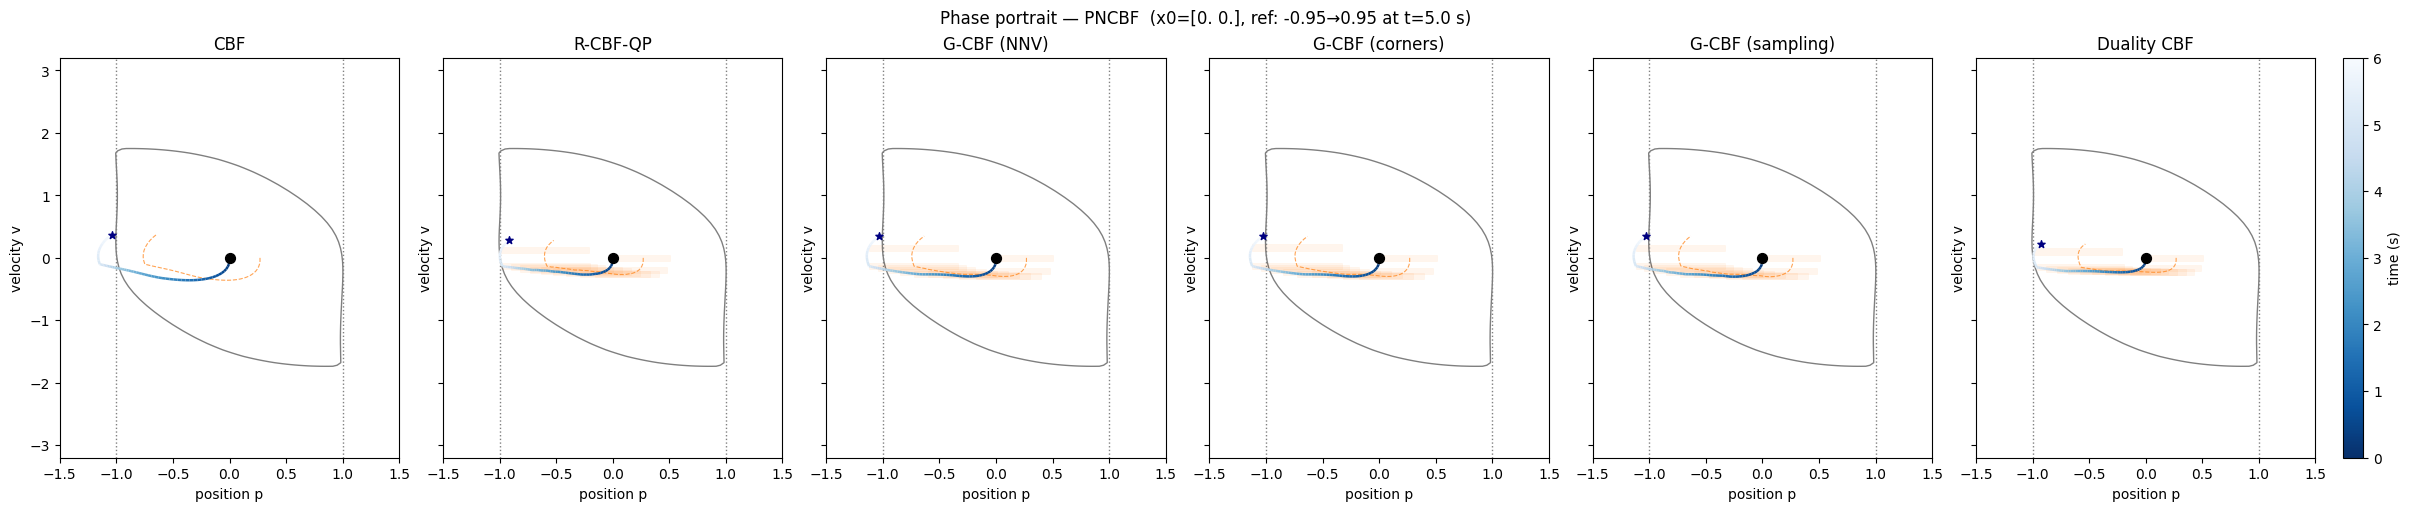

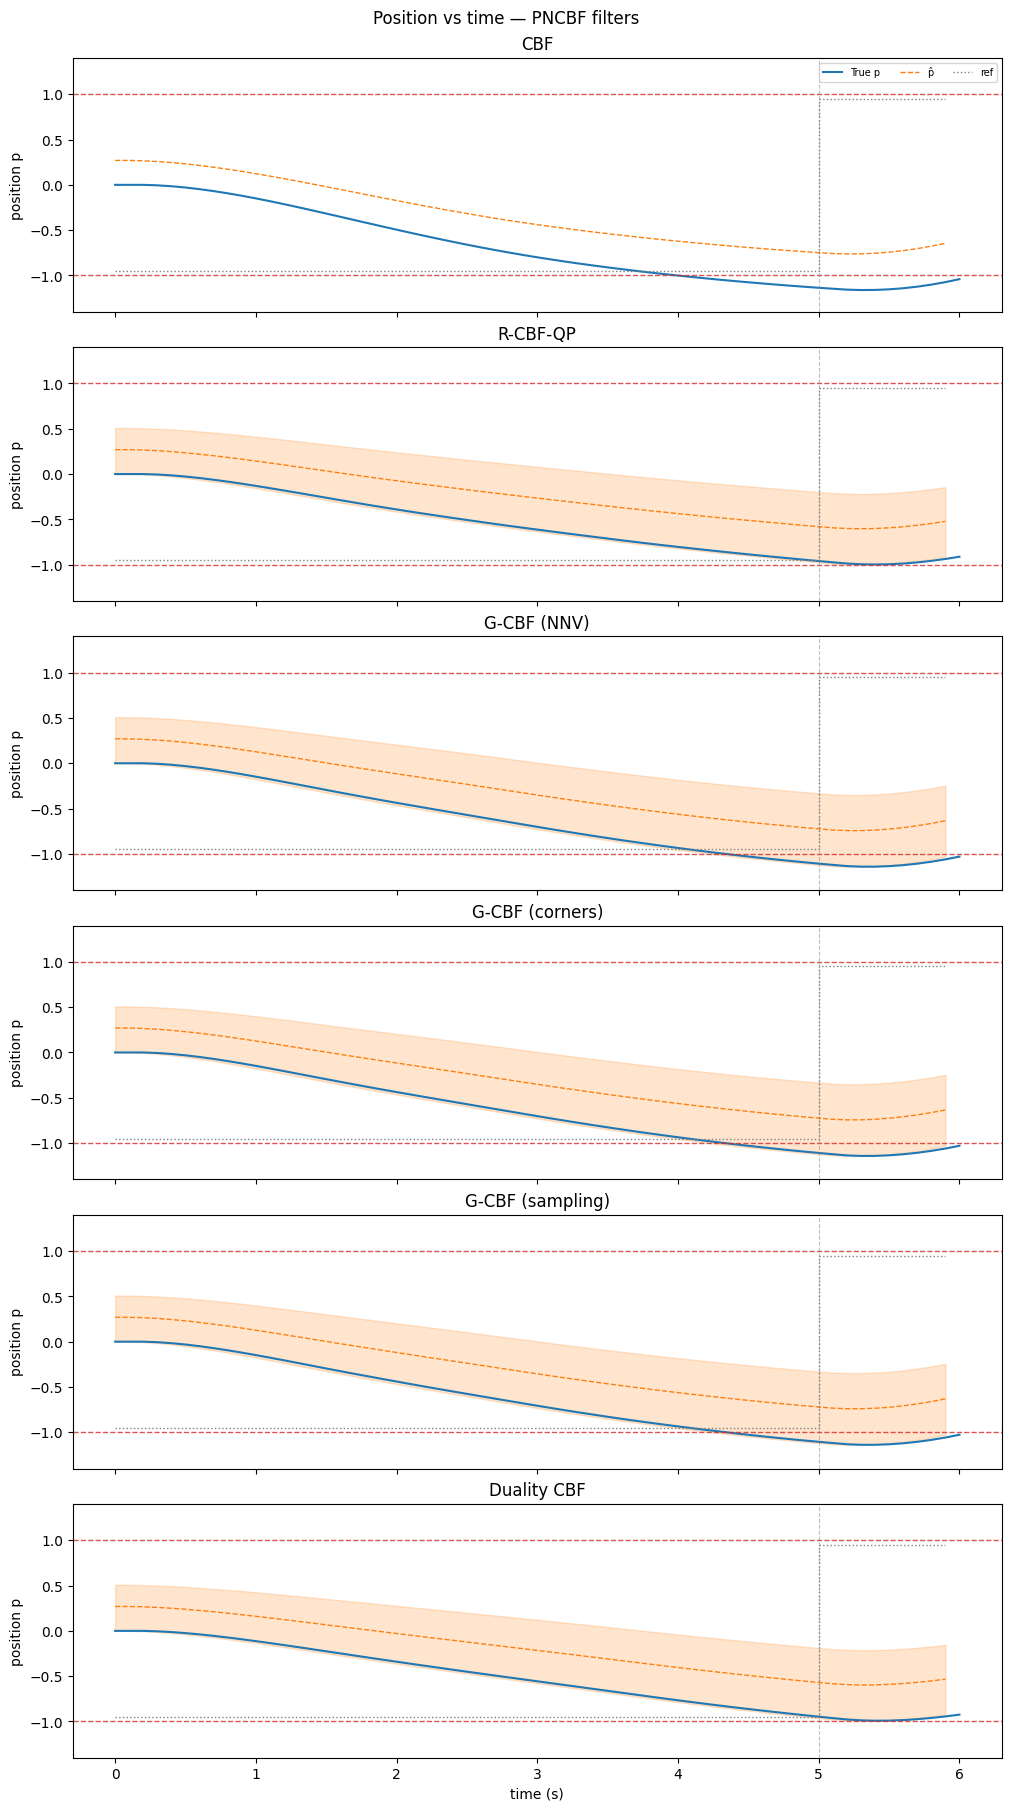

In [108]:
N_RCBF_SAMPLES = 20
N_PLANES_DUAL  = 8
_DUAL_COS = np.cos(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))
_DUAL_SIN = np.sin(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))

# ── R-CBF-QP ─────────────────────────────────────────────────────────────────
def _rcbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, samp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    x_pert = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, 2)) * (hi - lo)
    h_V_nom   = B_nn(xhat)
    hx_Vx_nom = jax.jacobian(B_nn)(xhat)
    u_nom     = nom_pol(xhat, ref)
    h_V_pert   = jax.vmap(B_nn)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_nn))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol(xp, ref))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=f(xhat), G_nom=G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert, n_grid=50)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_rcbf_aux = _make_rollout_aux(_rcbf_step_aux)

# ── Duality CBF ───────────────────────────────────────────────────────────────
def _duality_step_aux(x, step_ref):
    step_idx, ref    = step_ref
    key              = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, opt_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    u_nom_val = nom_pol(xhat, ref)

    def _ingr(xi):
        h  = B_nn(xi)
        Jh = jax.jacobian(B_nn)(xi)
        return h, Jh @ f(xi), Jh @ G(xi)

    h_pts, Lf_pts, LG_pts = [], [], []
    for i in range(_NH):
        for j in range(N_PLANES_DUAL):
            c_j  = float(_DUAL_COS[j])
            s_j  = float(_DUAL_SIN[j])
            k_ij = jax.random.fold_in(opt_key, i * N_PLANES_DUAL + j)
            def _dir_obj(xi, _c=c_j, _s=s_j, _i=i):
                h, Lf_h, LG_h = _ingr(xi)
                return _c * LG_h[_i, 0] + _s * (Lf_h[_i] + ALPHA_QP * h[_i])
            _, x_star = proj_grad_max_box(_dir_obj, lo, hi,
                                           n_restarts=4, n_steps=30, lr=0.05, key=k_ij)
            h_s, Lf_s, LG_s = _ingr(x_star)
            h_pts.append(h_s[i]); Lf_pts.append(Lf_s[i]); LG_pts.append(LG_s[i])

    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                       jnp.stack(h_pts), jnp.stack(Lf_pts), jnp.stack(LG_pts),
                       u_nom_val, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_duality_aux = _make_rollout_aux(_duality_step_aux)

print("Running R-CBF-QP and Duality CBF rollouts (includes JIT compile)...")
for label, fn in [("R-CBF-QP", rollout_rcbf_aux), ("Duality CBF", rollout_duality_aux), ("G-CBF (corners)", rollout_gcbf_corners_aux), ("G-CBF (sampling)", rollout_gcbf_sampling_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[label] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    print(f"  {label:<16}  violated: {viol}")

ALL_ROLLOUTS = [
    ("CBF",               results_aux["CBF"]),
    ("R-CBF-QP",          results_aux["R-CBF-QP"]),
    ("G-CBF (NNV)",       results_aux["G-CBF (NNV)"]),
    ("G-CBF (corners)",   results_aux["G-CBF (corners)"]),
    ("G-CBF (sampling)",  results_aux["G-CBF (sampling)"]),
    ("Duality CBF",       results_aux["Duality CBF"]),
]

# ── Phase portrait (4 panels) ─────────────────────────────────────────────────
BOX_STRIDE = 5
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(4*n_pol, 5),
                         layout="constrained", sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs, xhats, los, his = d['xs'], d['xhats'], d['los'], d['his']
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color='C1', lw=0.8, ls='--', alpha=0.7, label='x̂')
    if name != 'CBF':
        for i in range(0, T, BOX_STRIDE):
            w = float(his[i, 0] - los[i, 0])
            h = float(his[i, 1] - los[i, 1])
            from matplotlib.patches import Rectangle
            rect = Rectangle((float(los[i, 0]), float(los[i, 1])), w, h,
                              lw=0.4, edgecolor='C1', facecolor='C1', alpha=0.07, zorder=1)
            ax.add_patch(rect)
    ax.scatter(*xs[0],  s=50, color='k',    zorder=7)
    ax.scatter(*xs[-1], s=30, color='navy', marker='*', zorder=7)
    plot_phase(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle(f'Phase portrait — PNCBF  '
             f'(x0={np.array(x0_demo).round(2)}, '
             f'ref: {REF_INITIAL}→{REF_FINAL} at t={REF_SWITCH_STEP*DT:.1f} s)')
plt.show()

# ── Position vs time ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(n_pol, 1, figsize=(10, 3*n_pol),
                            sharex=True, layout="constrained")
for ax, (name, d) in zip(axes2, ALL_ROLLOUTS):
    if name != 'CBF':
        ax.fill_between(ts_ctrl, d['los'][:, 0], d['his'][:, 0],
                        color='C1', alpha=0.2, label='NNV bounds (p)')
    ax.plot(ts,      d['xs'][:, 0],    color='C0', lw=1.5, label='True p')
    ax.plot(ts_ctrl, d['xhats'][:, 0], color='C1', lw=1.0, ls='--', label='p̂')
    ax.step(ts_ctrl, ref_sched, color='gray', lw=1.0, ls=':', where='post', label='ref')
    ax.axhline( PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
    ax.axhline(-PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
    ax.axvline(REF_SWITCH_STEP*DT, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('position p'); ax.set_title(name); ax.set_ylim(-1.4, 1.4)
axes2[0].legend(fontsize=7, ncol=4)
axes2[-1].set_xlabel('time (s)')
fig2.suptitle('Position vs time — PNCBF filters')
plt.show()


In [109]:
# ── Duality CBF diagnostics ───────────────────────────────────────────────────
# Run this cell to check three things:
#   1. How wide is the NNV box in state space?
#   2. Is the gradient ascent actually moving from xhat?
#   3. Is the QP relaxation firing (r > 0 means infeasible constraints)?

x_diag = x0_demo
obs_d   = obs_fn(x_diag) + OBS_PTB
xhat_d  = estimator_fn(obs_d)
sb_d    = nnv_state_bounds(obs_d, OBS_EPS)
lo_d, hi_d = sb_d.lo, sb_d.hi

print("── Box width in state space ─────────────────────────────────────────")
print(f"  NNV box: lo={np.array(lo_d).round(4)}  hi={np.array(hi_d).round(4)}")
print(f"  Width  : {np.array(hi_d - lo_d).round(4)}")

print("\n── Duality gradient ascent: xhat vs ξ* ──────────────────────────────")
u_nom_d = nom_pol(xhat_d, float(REF_INITIAL))
h_nom, Lf_nom, LG_nom = _gcbf_ingredients(xhat_d)
print(f"  Nominal  h={np.array(h_nom).round(4)}  Lf={np.array(Lf_nom).round(4)}  LG={np.array(LG_nom).round(4)}")
key_d = jax.random.PRNGKey(7)
for i in range(_NH):
    for j in range(N_PLANES_DUAL):
        c_j = float(_DUAL_COS[j])
        s_j = float(_DUAL_SIN[j])
        k_ij = jax.random.fold_in(key_d, i * N_PLANES_DUAL + j)
        def _obj(xi, _c=c_j, _s=s_j, _i=i):
            h, Lf_h, LG_h = _gcbf_ingredients(xi)
            return _c * LG_h[_i, 0] + _s * (Lf_h[_i] + ALPHA_QP * h[_i])
        val_nom = _obj(xhat_d)
        val_star, xi_star = proj_grad_max_box(_obj, lo_d, hi_d,
                                               n_restarts=4, n_steps=30, lr=0.05, key=k_ij)
        moved = float(jnp.linalg.norm(xi_star - xhat_d))
        if j == 0:   # print first direction for each constraint
            print(f"  constraint {i}, dir {j} (c={c_j:.2f},s={s_j:.2f}): "
                  f"obj_nom={float(val_nom):.4f}  obj_star={float(val_star):.4f}  "
                  f"|ξ*-xhat|={moved:.4f}")

print("\n── QP relaxation (r>0 = constraints violated / infeasible) ──────────")
h_pts, Lf_pts, LG_pts = [], [], []
ci_all = jnp.arange(_NH)
for i in range(_NH):
    for j in range(N_PLANES_DUAL):
        c_j = float(_DUAL_COS[j]); s_j = float(_DUAL_SIN[j])
        k_ij = jax.random.fold_in(key_d, i * N_PLANES_DUAL + j)
        def _obj2(xi, _c=c_j, _s=s_j, _i=i):
            h, Lf_h, LG_h = _gcbf_ingredients(xi)
            return _c * LG_h[_i, 0] + _s * (Lf_h[_i] + ALPHA_QP * h[_i])
        _, xi_star = proj_grad_max_box(_obj2, lo_d, hi_d, n_restarts=4, n_steps=30, lr=0.05, key=k_ij)
        hs, Lfs, LGs = _gcbf_ingredients(xi_star)
        h_pts.append(hs[i]); Lf_pts.append(Lfs[i]); LG_pts.append(LGs[i])
u_d, r_d, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                        jnp.stack(h_pts), jnp.stack(Lf_pts), jnp.stack(LG_pts),
                        u_nom_d, relax_eps2=0.1)
print(f"  u_nom={float(u_nom_d[0]):.4f}  u_opt={float(u_d[0]):.4f}  "
      f"relaxation r={np.array(r_d).round(4)}")
print(f"  (u_opt ≈ u_nom with large r means QP is infeasible/over-relaxed)")


── Box width in state space ─────────────────────────────────────────
  NNV box: lo=[-0.   -0.05]  hi=[0.5083 0.05  ]
  Width  : [0.5083 0.1   ]

── Duality gradient ascent: xhat vs ξ* ──────────────────────────────
  Nominal  h=[-0.9024 -0.6793]  Lf=[0. 0.]  LG=[[-0.2245]
 [ 0.1615]]
  constraint 0, dir 0 (c=-1.00,s=-0.00): obj_nom=0.2245  obj_star=0.2489  |ξ*-xhat|=0.1347
  constraint 1, dir 0 (c=-1.00,s=-0.00): obj_nom=-0.1615  obj_star=-0.1010  |ξ*-xhat|=0.2386

── QP relaxation (r>0 = constraints violated / infeasible) ──────────
  u_nom=-1.0000  u_opt=-0.4581  relaxation r=0.12049999833106995
  (u_opt ≈ u_nom with large r means QP is infeasible/over-relaxed)


## Dual-Phi CBF: learning a scalar correction from dual-direction labels

Instead of solving a min-norm or G-CBF QP at runtime, we **learn** a scalar
correction $\phi_i(\hat{x}) \geq 0$ offline and apply it as a barrier tightening:
$$L_f V_i(\hat{x}) + L_G V_i(\hat{x})\,u + \alpha\bigl(V_i(\hat{x}) + \phi_i(\hat{x})/\alpha\bigr) \leq 0$$

**Label construction (dual):** For each dual direction $(c_j, s_j)$ find the sample
$\xi_j^* = \arg\max_{\xi \in [lo,hi]} \bigl[c_j \, L_G V_i(\xi) + s_j \, (L_f V_i(\xi) + \alpha V_i(\xi))\bigr]$,
then set
$$\phi_i(\hat{x}) = \max_j \max\bigl(0,\; [L_f V_i(\xi_j^*) + \alpha V_i(\xi_j^*)] - [L_f V_i(\hat{x}) + \alpha V_i(\hat{x})]\bigr)$$

Unlike the standard phi (which independently maximises $V$ and $L_f V$), the dual
label finds $\xi^*$ that is jointly worst-case for all ingredients — accounting for
$L_G V$ variation — and then measures the drift gap there.


In [117]:
import flax.linen as nn
import optax

N_LABEL_SAMPLES = 128   # random samples from [lo, hi] used to find dual ξ*

@jax.jit
def phi_dual_label(xhat, lo, hi, samp_key, alpha=ALPHA_QP):
    """
    Dual phi label: for each dual direction (c_j, s_j), find the sample from
    [lo, hi] that maximises c_j·LG_V_i + s_j·(Lf_V_i + α·V_i), then measure
    the drift increment at that ξ* vs nominal.

    Returns phi (nh,) >= 0.
    """
    samples = lo[None] + jax.random.uniform(
        samp_key, (N_LABEL_SAMPLES, lo.shape[0])) * (hi - lo)   # (N, nx)
    h_s, Lf_s, LG_s = jax.vmap(_gcbf_ingredients)(samples)      # (N,nh), (N,nh), (N,nh,nu)

    h_nom, Lf_nom, _ = _gcbf_ingredients(xhat)
    drift_nom = Lf_nom + alpha * h_nom    # (nh,)

    phi = jnp.zeros(_NH)
    ci  = jnp.arange(_NH)
    for j in range(N_PLANES_DUAL):
        c_j = float(_DUAL_COS[j])
        s_j = float(_DUAL_SIN[j])
        # dual objective at every sample for every constraint  (N, nh)
        dual_obj = c_j * LG_s[:, :, 0] + s_j * (Lf_s + alpha * h_s)
        best     = jnp.argmax(dual_obj, axis=0)              # (nh,)
        drift_at_best = Lf_s[best, ci] + alpha * h_s[best, ci]   # (nh,)
        gap  = jnp.maximum(0.0, drift_at_best - drift_nom)
        phi  = jnp.maximum(phi, gap)

    return phi + 1e-2   # (nh,) >= 0

# ── Generate training dataset ─────────────────────────────────────────────────
N_TRAIN_PHI = 8000
N_TEST_PHI  = 2000

p_lo, p_hi = -0.9,  0.9
v_lo, v_hi = -2.5,  2.5

rng_d   = jax.random.PRNGKey(17)
rng_tr, rng_te = jax.random.split(rng_d)

# Sample true states, pass through obs model to get xhat and NNV bounds
def _make_phi_sample(x_true, samp_key):
    obs  = obs_fn(x_true)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    phi  = phi_dual_label(xhat, sb.lo, sb.hi, samp_key)
    return xhat, phi

p_tr = jax.random.uniform(rng_tr, (N_TRAIN_PHI,)) * (p_hi - p_lo) + p_lo
v_tr = jax.random.uniform(rng_d,  (N_TRAIN_PHI,)) * (v_hi - v_lo) + v_lo
x_tr = jnp.stack([p_tr, v_tr], axis=1)

p_te = jax.random.uniform(rng_te, (N_TEST_PHI,)) * (p_hi - p_lo) + p_lo
v_te = jax.random.uniform(rng_d,  (N_TEST_PHI,)) * (v_hi - v_lo) + v_lo
x_te = jnp.stack([p_te, v_te], axis=1)

print("Generating dual-phi training labels...")
keys_tr = jax.random.split(jax.random.PRNGKey(3), N_TRAIN_PHI)
keys_te = jax.random.split(jax.random.PRNGKey(4), N_TEST_PHI)

xhat_tr, phi_tr = jax.vmap(_make_phi_sample)(x_tr, keys_tr)
xhat_te, phi_te = jax.vmap(_make_phi_sample)(x_te, keys_te)
xhat_tr, phi_tr = jax.device_get(xhat_tr), jax.device_get(phi_tr)
xhat_te, phi_te = jax.device_get(xhat_te), jax.device_get(phi_te)

print(f"phi stats — mean: {float(phi_tr.mean()):.4f}  "
      f"std: {float(phi_tr.std()):.4f}  "
      f"min: {float(phi_tr.min()):.4f}  "
      f"max: {float(phi_tr.max()):.4f}")


Generating dual-phi training labels...
phi stats — mean: 0.1979  std: 0.1977  min: 0.0101  max: 1.1596


PhiNet params: 1218
Epoch 100  train_loss=1.10e-03  val_mse=5.60e-04
Epoch 200  train_loss=2.19e-04  val_mse=1.33e-04
Epoch 300  train_loss=2.43e-04  val_mse=1.10e-04


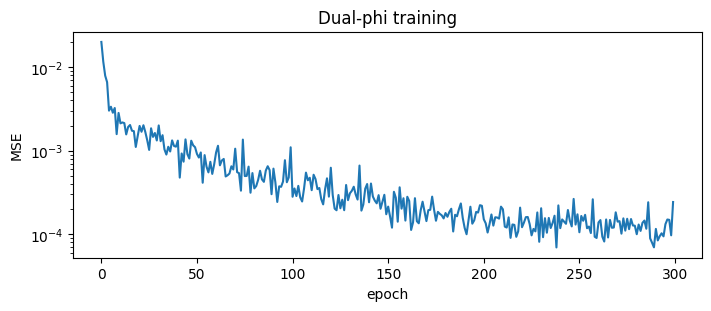

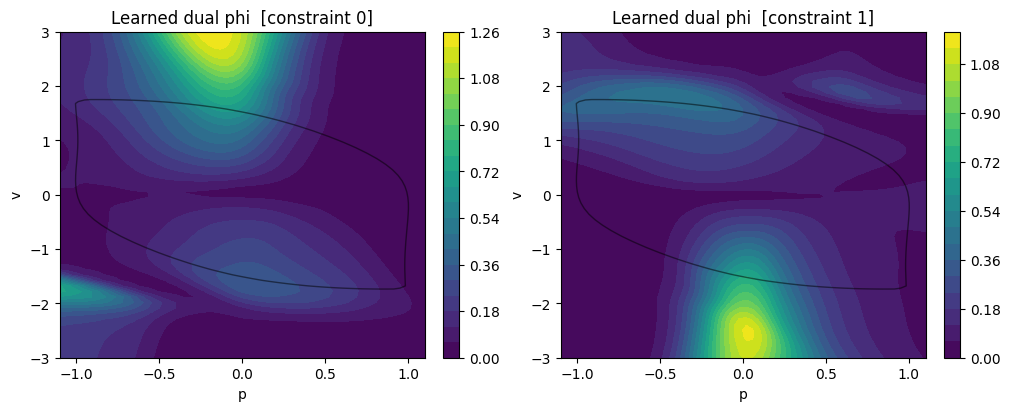

In [118]:
# ── PhiNet definition ─────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    hidden_dims: tuple = (32, 32)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat):
        x = xhat
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.tanh(x)
        return nn.softplus(nn.Dense(self.n_constraints)(x))   # phi >= 0 always

phi_net   = PhiNet()
phi_params = phi_net.init(jax.random.PRNGKey(0), jnp.zeros(2))['params']
phi_opt   = optax.adam(3e-3)
phi_opt_state = phi_opt.init(phi_params)

print(f"PhiNet params: {sum(p.size for p in jax.tree_util.tree_leaves(phi_params))}")

# ── Training loop ──────────────────────────────────────────────────────────────
BATCH_SIZE_PHI = 64
N_EPOCHS_PHI   = 300

@jax.jit
def phi_train_step(params, opt_state, xhat_b, phi_b):
    def loss_fn(p):
        pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xhat_b)
        return jnp.mean((pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = phi_opt.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(99)
phi_losses = []
for epoch in range(N_EPOCHS_PHI):
    rng_ep, rng_sh = jax.random.split(rng_ep)
    perm = np.array(jax.random.permutation(rng_sh, N_TRAIN_PHI))
    for b in range(0, N_TRAIN_PHI, BATCH_SIZE_PHI):
        idx = perm[b : b + BATCH_SIZE_PHI]
        phi_params, phi_opt_state, loss = phi_train_step(
            phi_params, phi_opt_state,
            jnp.array(xhat_tr[idx]), jnp.array(phi_tr[idx]))
        loss = float(loss)
    phi_losses.append(loss)
    if (epoch + 1) % 100 == 0:
        pred_te = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(jnp.array(xhat_te))
        val_mse = float(jnp.mean((pred_te - jnp.array(phi_te)) ** 2))
        print(f"Epoch {epoch+1:3d}  train_loss={loss:.2e}  val_mse={val_mse:.2e}")

fig, ax = plt.subplots(figsize=(7, 3), layout="constrained")
ax.semilogy(phi_losses)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("Dual-phi training")
plt.show()

# ── Phi grid visualisation ────────────────────────────────────────────────────
phi_grid_pred = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(grid_x)
fig, axes = plt.subplots(1, _NH, figsize=(5*_NH, 4), layout="constrained")
axes = np.atleast_1d(axes)
labels_h = [f'constraint {i}' for i in range(_NH)]
for ci_idx, ax in enumerate(axes):
    im = ax.contourf(PP, VV, np.array(phi_grid_pred[:, ci_idx]).reshape(n_pts, n_pts),
                     levels=20, cmap='viridis')
    ax.contour(PP, VV, Vh_grid, levels=[0.0], colors=['k'], linewidths=1.0, alpha=0.5)
    fig.colorbar(im, ax=ax)
    ax.set_title(f'Learned dual phi  [{labels_h[ci_idx]}]')
    ax.set_xlabel('p'); ax.set_ylabel('v')
plt.show()


Compiling dual-phi rollout...
Done.
  Dual Phi          violated: False


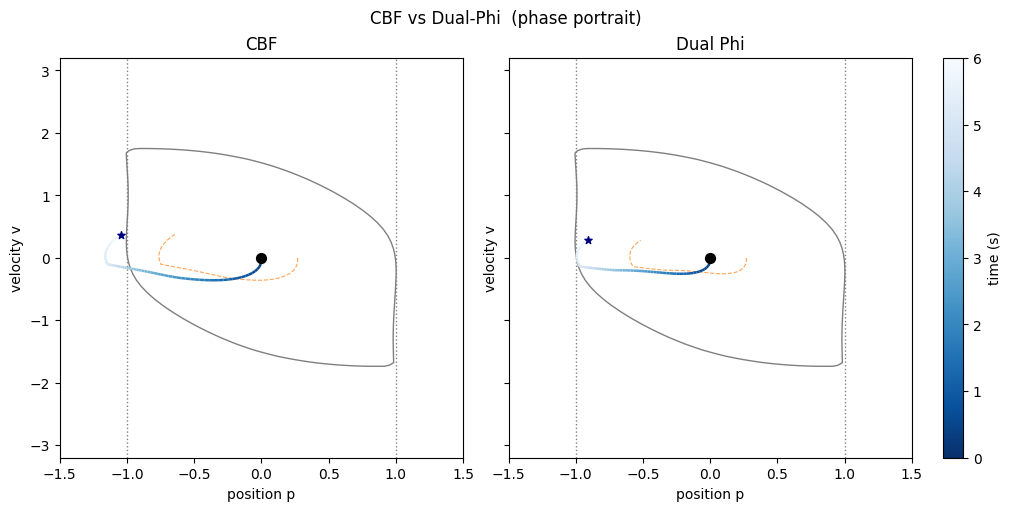

In [119]:
# ── Dual-phi online policy ───────────────────────────────────────────────────
_phi_params_frozen = phi_params   # snapshot for JIT

def _dual_phi_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, _ = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)

    h_V   = B_nn(xhat)
    hx_Vx = jax.jacobian(B_nn)(xhat)        # nominal gradient at x̂
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat)   # (nh,) >= 0

    # Tighten the effective barrier: h_tight = h_V + phi/alpha
    h_tight = h_V + phi / ALPHA_QP
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, hx_Vx,
                            f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, xhat, xhat)   # no box to show

rollout_dual_phi_aux = _make_rollout_aux(_dual_phi_step_aux)
print("Compiling dual-phi rollout...")
rollout_dual_phi_aux(x_dummy)
print("Done.")

# ── Run dual-phi rollout and add to results ───────────────────────────────────
xs_dp, xhats_dp, los_dp, his_dp = jax.device_get(rollout_dual_phi_aux(x0_demo))
results_aux["Dual Phi"] = dict(xs=xs_dp, xhats=xhats_dp, los=los_dp, his=his_dp)
viol_dp = bool(np.any(np.abs(xs_dp[:, 0]) > PWALL + 1e-3))
print(f"  {'Dual Phi':<16}  violated: {viol_dp}")

# Quick comparison: CBF vs Dual Phi phase portrait
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained", sharex=True, sharey=True)
for ax, name in zip(axes, ["CBF", "Dual Phi"]):
    d = results_aux[name]
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color='C1', lw=0.8, ls='--', alpha=0.7, label='x̂')
    ax.scatter(*xs[0],  s=50, color='k',    zorder=7)
    ax.scatter(*xs[-1], s=30, color='navy', marker='*', zorder=7)
    plot_phase(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle('CBF vs Dual-Phi  (phase portrait)')
plt.show()


In [125]:
N_RCBF_SAMPLES = 20
N_PLANES_DUAL  = 3
_DUAL_COS = np.cos(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))
_DUAL_SIN = np.sin(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))

# ── R-CBF-QP ─────────────────────────────────────────────────────────────────
def _rcbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, samp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    x_pert = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, 2)) * (hi - lo)
    h_V_nom   = B_nn(xhat)
    hx_Vx_nom = jax.jacobian(B_nn)(xhat)
    u_nom     = nom_pol(xhat, ref)
    h_V_pert   = jax.vmap(B_nn)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_nn))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol(xp, ref))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=f(xhat), G_nom=G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert, n_grid=50)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_rcbf_aux = _make_rollout_aux(_rcbf_step_aux)

# ── Duality CBF ───────────────────────────────────────────────────────────────
def _duality_step_aux(x, step_ref):
    step_idx, ref    = step_ref
    key              = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, opt_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    u_nom_val = nom_pol(xhat, ref)

    def _ingr(xi):
        h  = B_nn(xi)
        Jh = jax.jacobian(B_nn)(xi)
        return h, Jh @ f(xi), Jh @ G(xi)

    h_pts, Lf_pts, LG_pts = [], [], []
    for i in range(_NH):
        for j in range(N_PLANES_DUAL):
            c_j  = float(_DUAL_COS[j])
            s_j  = float(_DUAL_SIN[j])
            k_ij = jax.random.fold_in(opt_key, i * N_PLANES_DUAL + j)
            def _dir_obj(xi, _c=c_j, _s=s_j, _i=i):
                h, Lf_h, LG_h = _ingr(xi)
                return _c * LG_h[_i, 0] + _s * (Lf_h[_i] + ALPHA_QP * h[_i])
            _, x_star = proj_grad_max_box(_dir_obj, lo, hi,
                                           n_restarts=4, n_steps=30, lr=0.05, key=k_ij)
            h_s, Lf_s, LG_s = _ingr(x_star)
            h_pts.append(h_s[i]); Lf_pts.append(Lf_s[i]); LG_pts.append(LG_s[i])

    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                       jnp.stack(h_pts), jnp.stack(Lf_pts), jnp.stack(LG_pts),
                       u_nom_val, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_duality_aux = _make_rollout_aux(_duality_step_aux)

print("Running R-CBF-QP and Duality CBF rollouts (includes JIT compile)...")
for label, fn in [("R-CBF-QP", rollout_rcbf_aux), ("Duality CBF", rollout_duality_aux), ("G-CBF (corners)", rollout_gcbf_corners_aux), ("G-CBF (sampling)", rollout_gcbf_sampling_aux), ("Dual Phi", rollout_dual_phi_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[label] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    print(f"  {label:<16}  violated: {viol}")

ALL_ROLLOUTS = [
    ("CBF",               results_aux["CBF"]),
    ("R-CBF-QP",          results_aux["R-CBF-QP"]),
    ("G-CBF (NNV)",       results_aux["G-CBF (NNV)"]),
    ("G-CBF (corners)",   results_aux["G-CBF (corners)"]),
    ("G-CBF (sampling)",  results_aux["G-CBF (sampling)"]),
    ("Dual Phi",          results_aux["Dual Phi"]),
    ("Duality CBF",       results_aux["Duality CBF"]),
]




Running R-CBF-QP and Duality CBF rollouts (includes JIT compile)...
  R-CBF-QP          violated: False
  Duality CBF       violated: False
  G-CBF (corners)   violated: True
  G-CBF (sampling)  violated: True
  Dual Phi          violated: False


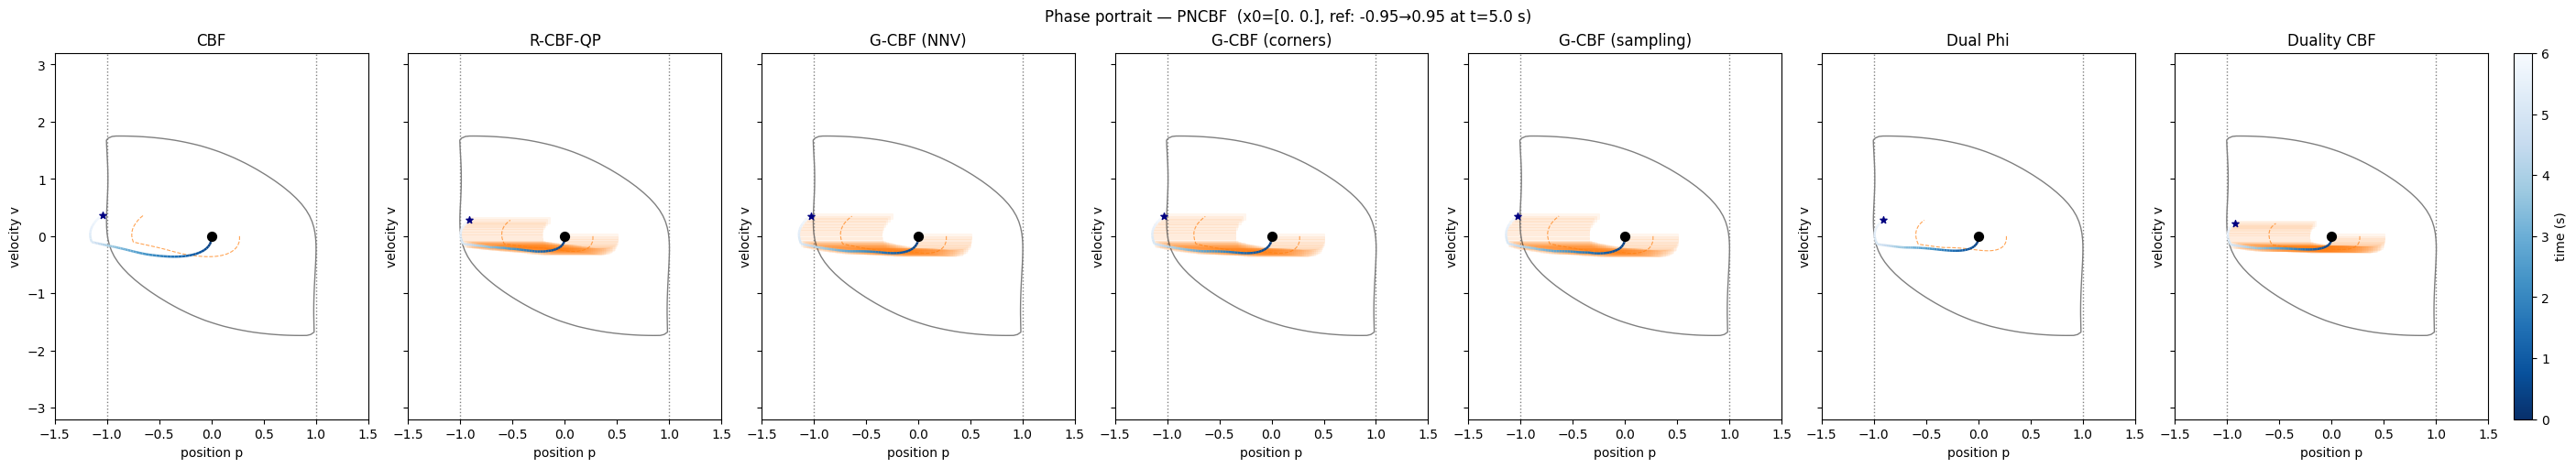

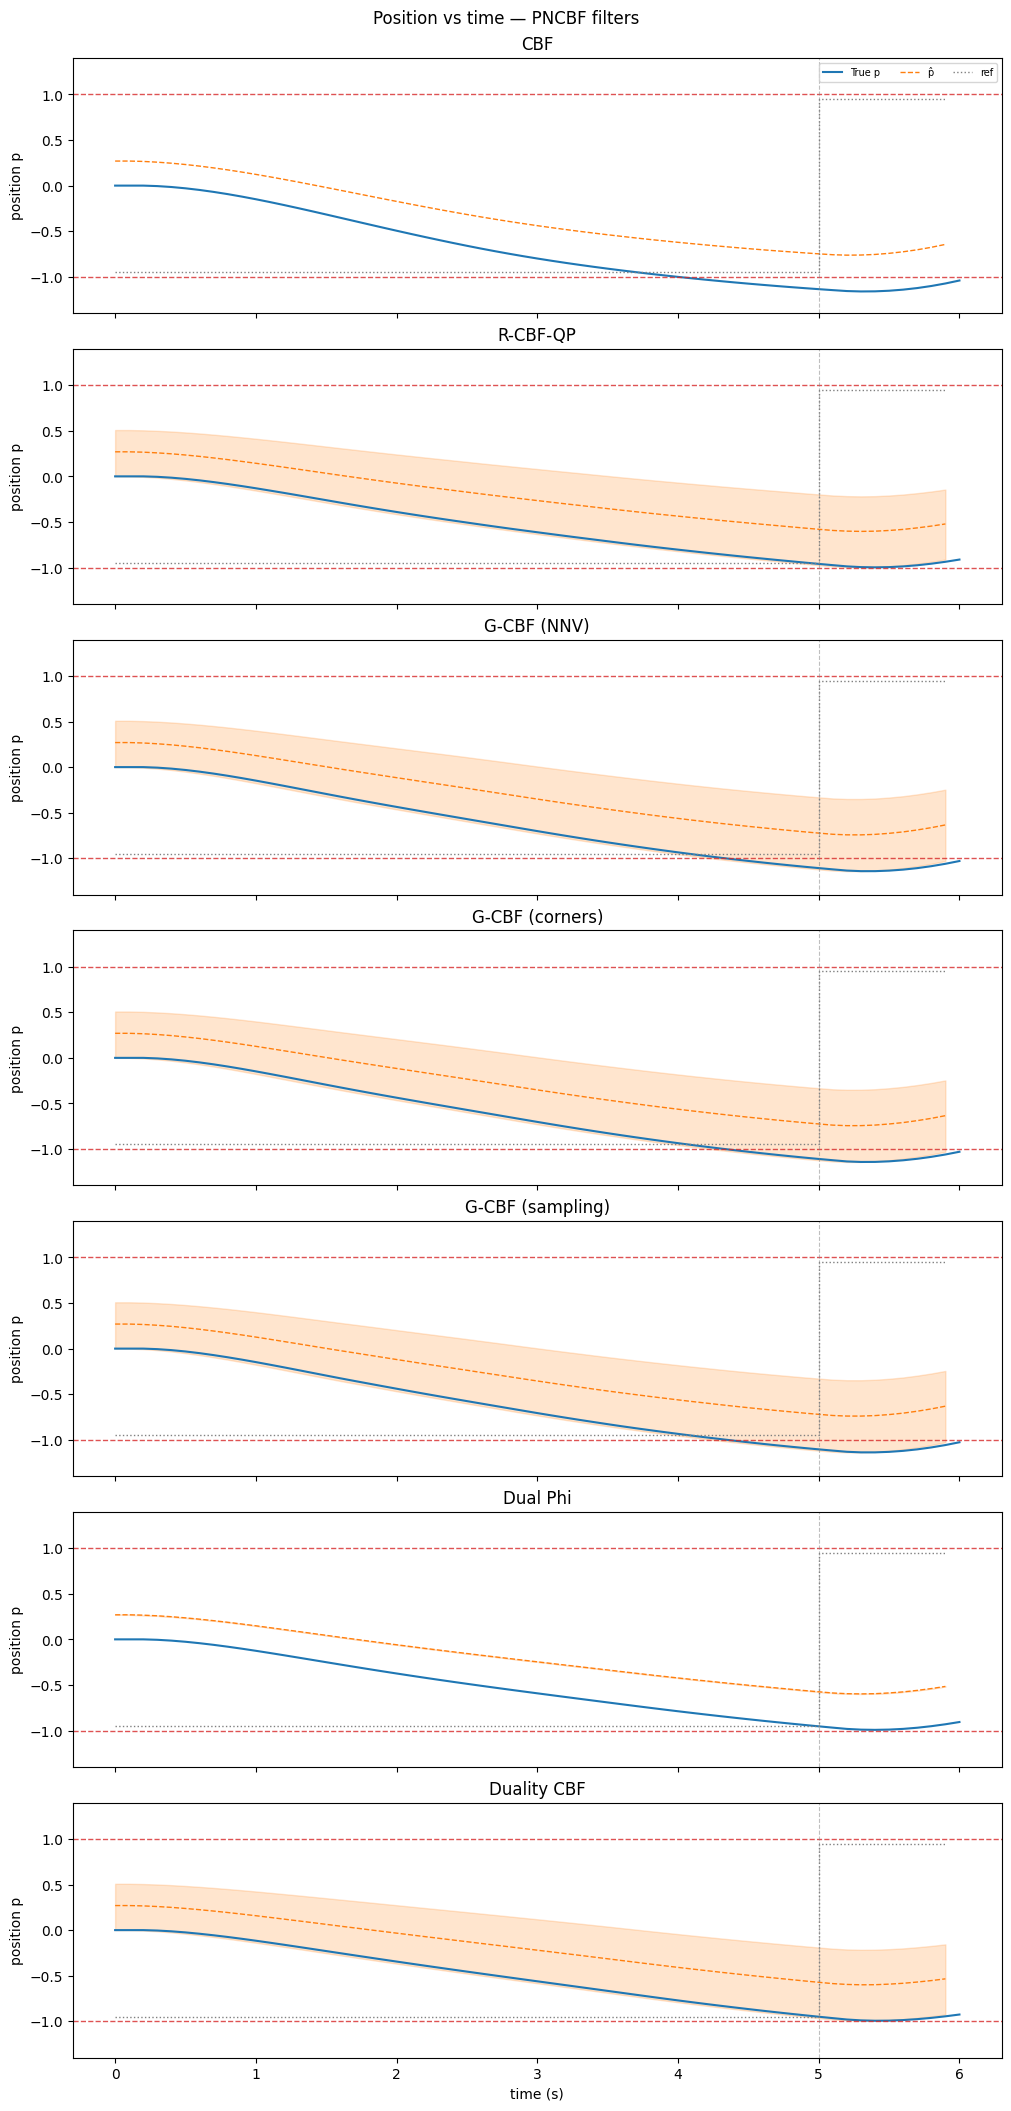

In [126]:
# ── Phase portrait (4 panels) ─────────────────────────────────────────────────
BOX_STRIDE = 1
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(4*n_pol, 5),
                         layout="constrained", sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs, xhats, los, his = d['xs'], d['xhats'], d['los'], d['his']
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color='C1', lw=0.8, ls='--', alpha=0.7, label='x̂')
    if name != 'CBF':
        for i in range(0, T, BOX_STRIDE):
            w = float(his[i, 0] - los[i, 0])
            h = float(his[i, 1] - los[i, 1])
            from matplotlib.patches import Rectangle
            rect = Rectangle((float(los[i, 0]), float(los[i, 1])), w, h,
                              lw=0.4, edgecolor='C1', facecolor='C1', alpha=0.07, zorder=1)
            ax.add_patch(rect)
    ax.scatter(*xs[0],  s=50, color='k',    zorder=7)
    ax.scatter(*xs[-1], s=30, color='navy', marker='*', zorder=7)
    plot_phase(ax)
    ax.set_title(name)
fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle(f'Phase portrait — PNCBF  '
             f'(x0={np.array(x0_demo).round(2)}, '
             f'ref: {REF_INITIAL}→{REF_FINAL} at t={REF_SWITCH_STEP*DT:.1f} s)')
plt.show()

# ── Position vs time ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(n_pol, 1, figsize=(10, 3*n_pol),
                            sharex=True, layout="constrained")
for ax, (name, d) in zip(axes2, ALL_ROLLOUTS):
    if name != 'CBF':
        ax.fill_between(ts_ctrl, d['los'][:, 0], d['his'][:, 0],
                        color='C1', alpha=0.2, label='NNV bounds (p)')
    ax.plot(ts,      d['xs'][:, 0],    color='C0', lw=1.5, label='True p')
    ax.plot(ts_ctrl, d['xhats'][:, 0], color='C1', lw=1.0, ls='--', label='p̂')
    ax.step(ts_ctrl, ref_sched, color='gray', lw=1.0, ls=':', where='post', label='ref')
    ax.axhline( PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
    ax.axhline(-PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
    ax.axvline(REF_SWITCH_STEP*DT, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('position p'); ax.set_title(name); ax.set_ylim(-1.4, 1.4)
axes2[0].legend(fontsize=7, ncol=4)
axes2[-1].set_xlabel('time (s)')
fig2.suptitle('Position vs time — PNCBF filters')
plt.show()

Timing 5 rollouts  (T=60 steps, dt=0.1)

  Policy              Mean (s)     Std (s)   Per-step (ms)
  --------------------------------------------------------
  CBF                   0.0607      0.0195           1.012
  R-CBF-QP              0.0476      0.0040           0.794
  G-CBF (NNV)           0.3659      0.0007           6.098
  G-CBF (corners)       0.0503      0.0004           0.838
  G-CBF (sampling)      0.0518      0.0001           0.863
  Dual Phi              0.0456      0.0001           0.761
  Duality CBF           0.4120      0.0002           6.867


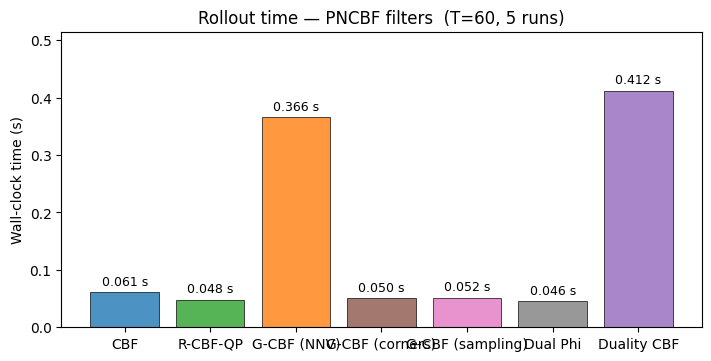

: 

In [ ]:
ROLLOUT_FNS = [
    ("CBF",               rollout_cbf_aux),
    ("R-CBF-QP",          rollout_rcbf_aux),
    ("G-CBF (NNV)",       rollout_gcbf_aux),
    ("G-CBF (corners)",   rollout_gcbf_corners_aux),
    ("G-CBF (sampling)",  rollout_gcbf_sampling_aux),
    ("Dual Phi",          rollout_dual_phi_aux),
    ("Duality CBF",       rollout_duality_aux),
]
N_REPEATS = 5

print(f"Timing {N_REPEATS} rollouts  (T={T} steps, dt={DT})\n")
print(f"  {'Policy':<16}  {'Mean (s)':>10}  {'Std (s)':>10}  {'Per-step (ms)':>14}")
print("  " + "-"*56)

timing_results = {}
for name, fn in ROLLOUT_FNS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(x0_demo))
        times.append(time.perf_counter() - t0)
    mean_t = float(np.mean(times))
    timing_results[name] = mean_t
    print(f"  {name:<16}  {mean_t:>10.4f}  {float(np.std(times)):>10.4f}  {mean_t/T*1000:>14.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
names  = [n for n, _ in ROLLOUT_FNS]
values = [timing_results[n] for n in names]
bars = ax.bar(names, values, color=["C0","C2","C1","C5","C6","C7","C4"],
              alpha=0.8, edgecolor="k", linewidth=0.6)
ax.bar_label(bars, fmt="{:.3f} s", padding=3, fontsize=9)
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Rollout time — PNCBF filters  (T={T}, {N_REPEATS} runs)")
ax.set_ylim(0, max(values)*1.25)
plt.show()
